## Домашнее задание: Разработка рекомендательной системы для музыки на платформе Spotify

1. Предобработка данных и EDA

Необходимо провести анализ данных (Exploratory Data Analysis, EDA) для понимания структуры датасетов и подготовки данных к разработке рекомендательной системы: 
- Загрузка данных и очистка выбросов
- Рассчитайте основные статистики для числовых колонок: среднее, медиану, стандартное отклонение, минимумы и максимумы.
- Проведите корреляционный анализ между различными признаками (например, между valence, energy, danceability и другими признаками).
- Постройте гистограммы и коробочные диаграммы для визуализации распределений числовых признаков.
- Анализ категориальных данных
- Постройте тепловую карту корреляции между признаками.

2. Разработка рекомендательной системы (Контентная фильтрация)

В этой части задания необходимо разработать рекомендательную систему, которая будет основывать свои рекомендации на характеристиках самих песен.

- Построение модели на основе контента. Используйте признаки, чтобы рекомендовать похожие песни по жанрам и стилю.
- Проведите кластеризацию для улучшения рекомендаций на основе признаков с использованием алгоритмов, таких как K-means или DBSCAN. Рекомендуйте песни, которые находятся в одном кластере с уже выбранной песней.

3. Построение гибридной модели
- Разработайте гибридную рекомендательную систему, которая сочетает контентную фильтрацию и методы кластеризации признаков. Таким образом, рекомендации могут быть основаны как на схожести признаков, так и на принадлежности песен к определённым группам (кластерам).

4. Оценка качества модели

После того как модели будут построены, необходимо провести их оценку.

- Создайте свой валидационный набор в группе студентов. Каждому из студентов необходимо выбрать по 30 песен, которые ему нравятся. Желательно разных исполнителей. Объедините данные в группе и создайте единый набор.
- Оцените свою модель с помощью метрик precision/recall at K на разных параметрах и объясните полученный результат. 

In [1]:
import os
import sys
import random
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [2]:
data_path = "data/data.csv"
df = pd.read_csv(data_path)

print(f"Датасет: {df.shape}")

if "release_date" in df.columns:
    df["year_extracted"] = df["release_date"].astype(str).str.extract(r"(\d{4})").astype(float)
    df = df.drop(columns=["year_extracted", "release_date"], errors="ignore")

exclude_cols = ["artists", "id", "name", "explicit", "mode"]
num_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Числовых признаков: {len(num_cols)}")

Датасет: (170653, 19)
Числовых признаков: 13


In [3]:
skew_values = df[num_cols].skew()
pos_skew_cols = skew_values[skew_values > 1.0].index.tolist()
neg_skew_cols = skew_values[skew_values < -1.0].index.tolist()

df_cleaned = df.copy()
init_rows = df_cleaned.shape[0]
quantile_limit = 0.985

for col in pos_skew_cols:
    limit = df_cleaned[col].quantile(quantile_limit)
    df_cleaned = df_cleaned[df_cleaned[col] <= limit]

removed_pct = (init_rows - df_cleaned.shape[0]) / init_rows * 100

for col in pos_skew_cols:
    df_cleaned[col] = np.power(df_cleaned[col], 1 / 10)

for col in neg_skew_cols:
    constant = df_cleaned[col].max() + 1
    df_cleaned[col] = np.log(constant - df_cleaned[col])

df = df_cleaned.reset_index(drop=True)

print(f"Скорректирована асимметрия. Удалено выбросов: {removed_pct:.2f}%")

Скорректирована асимметрия. Удалено выбросов: 5.79%


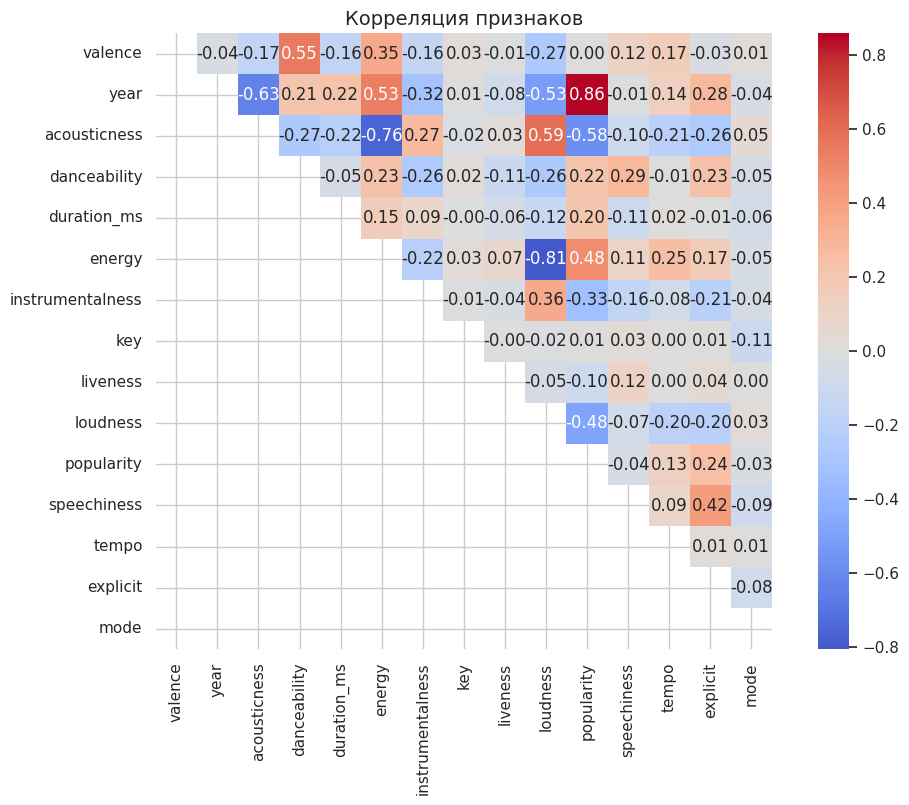

Удалены скоррелированные признаки: ['loudness']


In [4]:
target_cols = num_cols + ["explicit", "mode"]
corr_matrix = df[target_cols].corr()

plt.figure(figsize=(12, 8))
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Корреляция признаков", fontsize=14)
plt.show()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = ['loudness']
df = df.drop(columns=to_drop, errors="ignore")
num_cols = [col for col in num_cols if col not in to_drop]

print(f"Удалены скоррелированные признаки: {to_drop}")

Удалтл loudness из-за высокой корреляции с energy

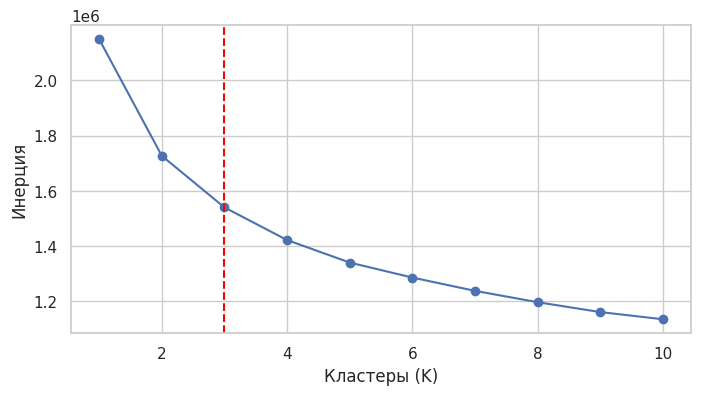

Размер кластеров: {1: 82078, 0: 65855, 2: 12847}


In [5]:
cluster_features = num_cols + ["explicit", "mode"]

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[cluster_features])

pca = PCA(n_components=0.95, random_state=42)
pca_data = pca.fit_transform(scaled_data)

inertia = []
cluster_range = range(1, 11)

for k in cluster_range:
    km = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )
    km.fit(pca_data)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(cluster_range, inertia, "o-")
plt.xlabel("Кластеры (K)")
plt.ylabel("Инерция")
plt.axvline(x=3, color="red", linestyle="--")
plt.show()

optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, init="k-means++", n_init=10, random_state=42)
df["cluster"] = kmeans.fit_predict(pca_data)

print(f"Размер кластеров: {df['cluster'].value_counts().to_dict()}")

Использовал NearestNeighbors, добавил фильтрацию по кластеру

In [6]:
class MusicRecommender:

    def __init__(self, dataframe, feature_cols):
        self.df = dataframe.copy()
        self.feature_cols = [col for col in feature_cols if col in self.df.columns]

        self.scaler = StandardScaler()
        self.scaled_features = self.scaler.fit_transform(self.df[self.feature_cols])

        self.nn = NearestNeighbors(n_neighbors=250, metric="cosine", algorithm="brute")
        self.nn.fit(self.scaled_features)

    def recommend_content(self, track_idx, top_k=10, filter_by_cluster=True):
        if track_idx >= len(self.df):
            return [], []

        track_vec = self.scaled_features[track_idx:track_idx + 1]
        distances, indices = self.nn.kneighbors(track_vec, n_neighbors=top_k + 50)

        similarities = 1 - distances.flatten()
        indices = indices.flatten()

        mask = indices != track_idx
        cand_indices = indices[mask]
        cand_sims = similarities[mask]

        if filter_by_cluster and "cluster" in self.df.columns:
            target_cluster = self.df.at[track_idx, "cluster"]
            cluster_labels = self.df.iloc[cand_indices]["cluster"].values
            cluster_mask = cluster_labels == target_cluster
            cand_indices = cand_indices[cluster_mask]
            cand_sims = cand_sims[cluster_mask]

        top_order = np.argsort(cand_sims)[::-1][:top_k]

        return cand_indices[top_order], cand_sims[top_order]

    def recommend_hybrid(self, track_idx, top_k=10, alpha=0.5):
        if track_idx >= len(self.df):
            return [], []

        track_vec = self.scaled_features[track_idx:track_idx + 1]
        distances, indices = self.nn.kneighbors(track_vec, n_neighbors=top_k + 25)

        similarities = 1 - distances.flatten()
        indices = indices.flatten()

        mask = indices != track_idx
        cand_indices = indices[mask]
        cand_sims = similarities[mask]

        target_cluster = self.df.at[track_idx, "cluster"]
        cluster_labels = self.df.iloc[cand_indices]["cluster"].values
        cluster_bonus = (cluster_labels == target_cluster).astype(float)

        hybrid_scores = alpha * cand_sims + (1 - alpha) * cluster_bonus
        top_order = np.argsort(hybrid_scores)[::-1][:top_k]

        return cand_indices[top_order], hybrid_scores[top_order]


to_drop = ['loudness']
df = df.drop(columns=to_drop, errors="ignore")
num_cols = [col for col in num_cols if col not in to_drop]

feature_cols = [c for c in num_cols if c != 'popularity']

recommender = MusicRecommender(df, feature_cols)

In [7]:
import json

# Загружаем файл
with open('validation_file.json', 'r', encoding='utf-8') as f:
    validation_data = json.load(f)

all_val_indices_raw = []
for data in validation_data.values():
    all_val_indices_raw.extend(data["indices"])

val_indices = [idx for idx in all_val_indices_raw if idx < len(df)]
unique_val = len(set(val_indices))

print(f"Размер df: {len(df)}")
print(f"Уникальных валидационных индексов (после фильтра): {unique_val}")
print(f"Максимальный индекс в валидации: {max(all_val_indices_raw)}")
print(f"Пример индексов: {sorted(val_indices)[:10]}")

all_val_indices_raw = []
for data in validation_data.values():
    all_val_indices_raw.extend(data["indices"])

val_indices = sorted(list(set(idx for idx in all_val_indices_raw if idx < len(df))))

print(f"Уникальных валидационных треков: {len(val_indices)}")

Размер df: 160780
Уникальных валидационных индексов (после фильтра): 246
Максимальный индекс в валидации: 170476
Пример индексов: [1206, 1211, 3411, 4206, 4214, 8027, 8545, 8729, 8822, 9228]
Уникальных валидационных треков: 246


,count,mean,std,min,25%,50%,75%,max
valence,160780.0,0.535478,0.262033,0.000000,0.324000,0.547000,0.754000,1.000000
year,160780.0,1977.750180,25.629313,1921.000000,1957.000000,1979.000000,2000.000000,2020.000000
acousticness,160780.0,0.495414,0.376397,0.000000,0.095800,0.499000,0.889000,0.996000
danceability,160780.0,0.541384,0.174100,0.000000,0.421000,0.550000,0.669000,0.988000
duration_ms,160780.0,3.404547,0.126453,2.348687,3.336200,3.400910,3.478272,3.770680
energy,160780.0,0.489037,0.265359,0.000000,0.266000,0.481000,0.708000,1.000000
instrumentalness,160780.0,0.453350,0.353583,0.000000,0.000000,0.424274,0.771493,0.994148
key,160780.0,5.197294,3.509064,0.000000,2.000000,5.000000,8.000000,11.000000
liveness,160780.0,0.830516,0.056034,0.000000,0.792482,0.817307,0.870202,0.984111
popularity,160780.0,32.266103,21.689290,0.000000,13.000000,34.000000,49.000000,100.000000


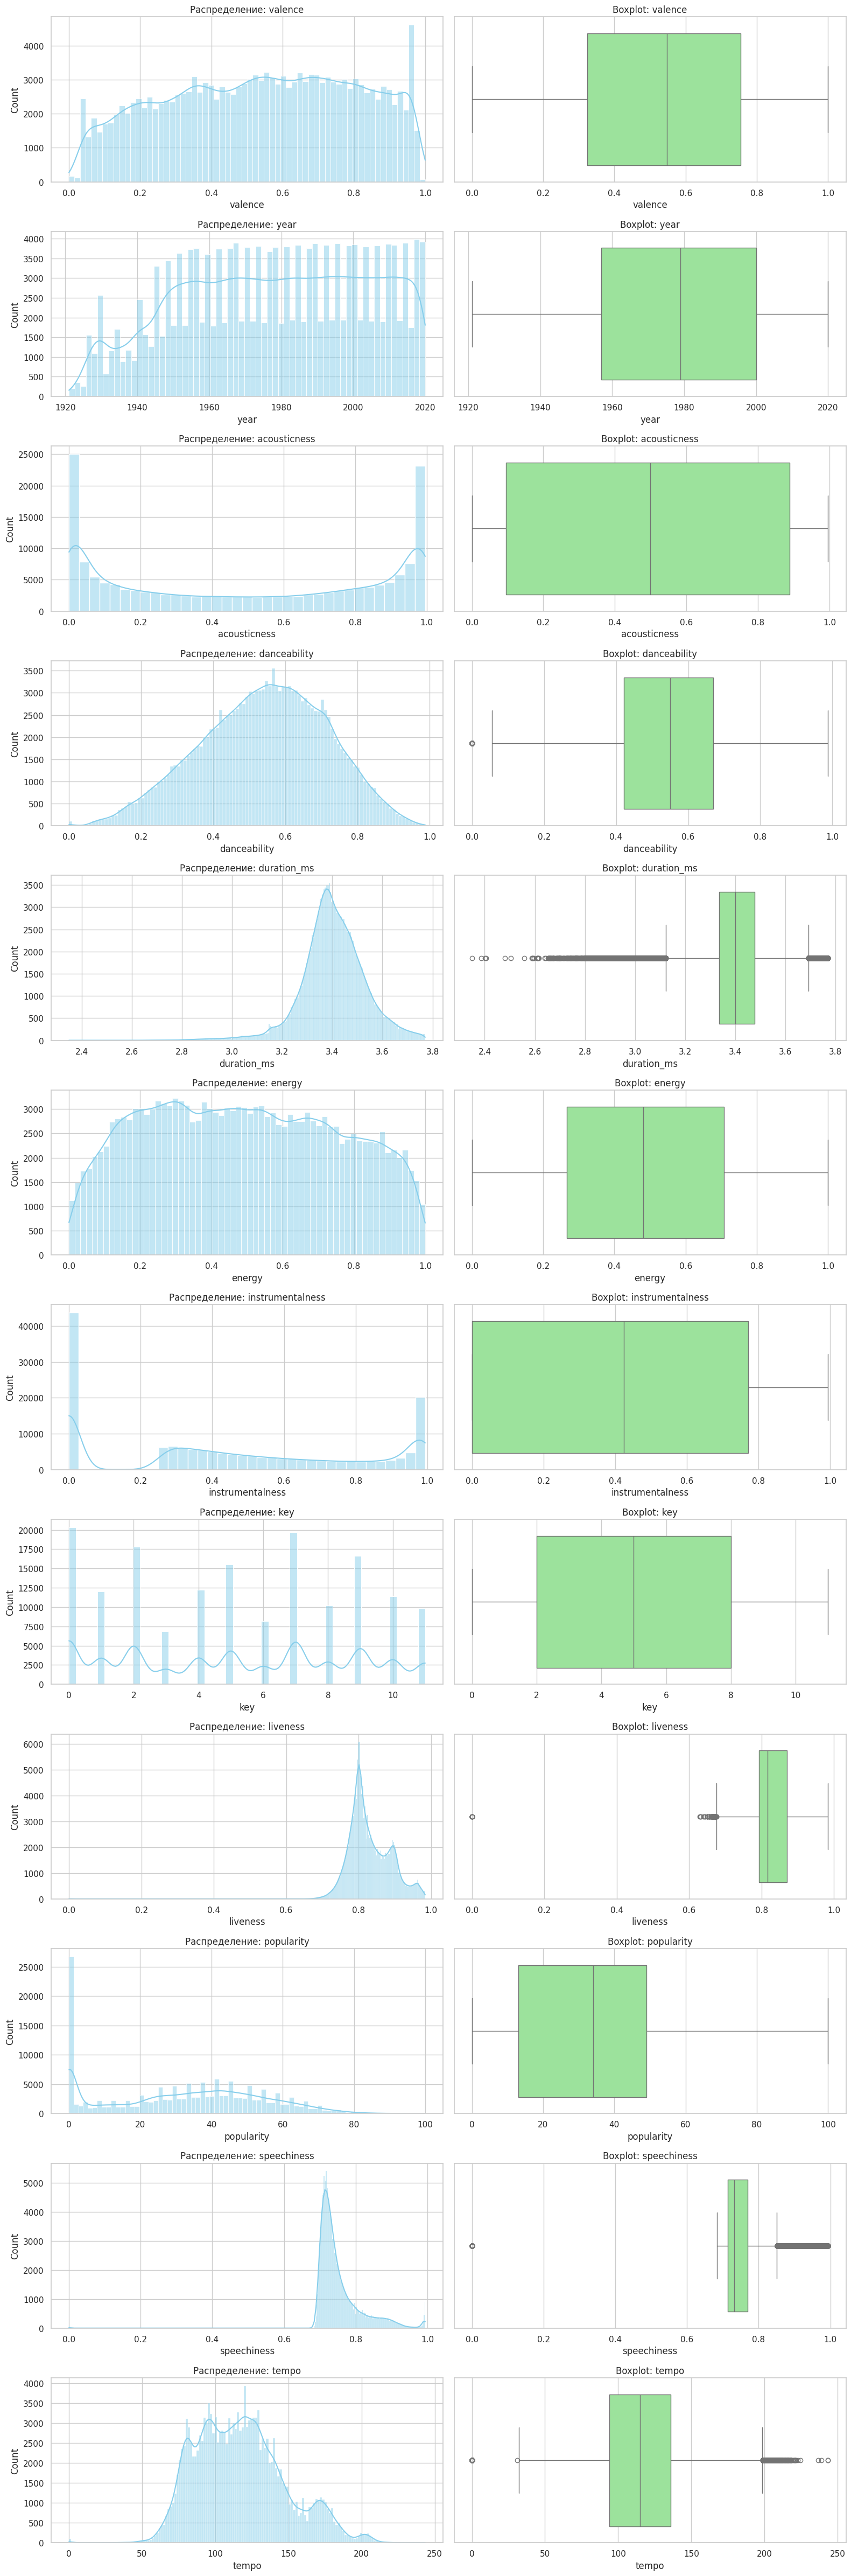

In [8]:
display(df[num_cols].describe().T)

fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(16, 4 * len(num_cols)))
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f"Распределение: {col}", fontsize=12)

    sns.boxplot(x=df[col], ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f"Boxplot: {col}", fontsize=12)

plt.tight_layout()
plt.show()

Оценку провёл по совпадению исполнителей, потому что точное совпадение треков из валидационного набора крайне маловероятно

In [9]:
def artist_precision_recall(recommended, relevant, k):
    recommended = recommended[:k]
    rel_artists = set(df.iloc[relevant]["artists"].values)

    hits = sum(1 for rec in recommended if df.at[rec, "artists"] in rel_artists)

    precision = hits / k
    recall = hits / len(relevant)

    return precision, recall

def evaluate_recommender_cv(user_data, top_k=50):
    precisions, recalls = [], []
    for student, info in user_data.items():
        history = [idx for idx in info["indices"] if idx < len(df)]
        if len(history) < 5:
            continue

        train_idx = history[:-5]
        test_idx = history[-5:]
        candidate_scores = {}

        for track_id in train_idx:
            track_vec = recommender.scaled_features[track_id].reshape(1, -1)
            distances, indices = recommender.nn.kneighbors(track_vec, n_neighbors=100)
            similarities = 1 - distances.flatten()

            for idx, sim in zip(indices.flatten(), similarities):
                if idx not in train_idx:
                    candidate_scores[idx] = candidate_scores.get(idx, 0) + sim

        top_recommendations = sorted(candidate_scores, key=candidate_scores.get, reverse=True)[:top_k]

        p, r = artist_precision_recall(top_recommendations, test_idx, top_k)

        precisions.append(p)
        recalls.append(r)

    return np.mean(precisions), np.mean(recalls)

k_values = [5, 10, 20, 50, 100, 200]
for k in k_values:
    p, r = evaluate_recommender_cv(validation_data, top_k=k)
    print(f"K = {k} | Precision: {p:.4f} | Recall: {r:.4f}")

K = 5 | Precision: 0.0000 | Recall: 0.0000
K = 10 | Precision: 0.0000 | Recall: 0.0000
K = 20 | Precision: 0.0000 | Recall: 0.0000
K = 50 | Precision: 0.0000 | Recall: 0.0000
K = 100 | Precision: 0.0000 | Recall: 0.0000
K = 200 | Precision: 0.0006 | Recall: 0.0250


В гибридной модели я объединил контентное сходство, кластер и небольшой бонус популярности

In [10]:
def generate_hybrid_recommendations(user_history, top_n=20):
    valid_history = [idx for idx in user_history if idx < len(df)]
    if not valid_history:
        return []

    candidate_scores = {}

    for track_id in valid_history:
        track_vec = recommender.scaled_features[track_id].reshape(1, -1)
        distances, indices = recommender.nn.kneighbors(track_vec, n_neighbors=150)
        similarities = 1 - distances.flatten()
        for idx, sim in zip(indices.flatten(), similarities):
            if idx not in valid_history:
                candidate_scores[idx] = candidate_scores.get(idx, 0) + sim

    user_clusters = df.iloc[valid_history]["cluster"].value_counts()
    dominant_cluster = user_clusters.index[0] if not user_clusters.empty else -1

    hybrid_scores = {}
    pop_norm = df['popularity'] / 100.0

    for idx, content_score in candidate_scores.items():
        cluster_bonus = 1.0 if df.at[idx, 'cluster'] == dominant_cluster else 0.0
        popularity_bonus = pop_norm.at[idx]

        hybrid_scores[idx] = (0.7 * content_score) + (0.2 * cluster_bonus) + (0.1 * popularity_bonus)

    best_options = sorted(hybrid_scores, key=hybrid_scores.get, reverse=True)[:top_n]
    return best_options

all_recommendations = {}
for student, info in validation_data.items():
    history = info["indices"]
    rec_ids = generate_hybrid_recommendations(history, top_n=20)
    all_recommendations[student] = rec_ids
    sample_tracks = df.iloc[rec_ids[:2]][["artists", "name"]].values.tolist()
    print(f"{student} -> Рекомендовано: {rec_ids[:3]}... Примеры: {sample_tracks}")

pavel_pranovich -> Рекомендовано: [np.int64(131024), np.int64(16074), np.int64(16487)]... Примеры: [["['Disturbed']", 'Living After Midnight'], ["['Muse']", 'Supermassive Black Hole']]
marina_tarasevich -> Рекомендовано: [np.int64(17045), np.int64(54100), np.int64(35381)]... Примеры: [["['Falling In Reverse']", 'The Drug In Me Is You'], ["['Jimmie Allen']", 'Make Me Want To']]
pavel_kupcevich -> Рекомендовано: [np.int64(87055), np.int64(132060), np.int64(132746)]... Примеры: [["['UPSAHL']", 'Drugs'], ["['Russ']", 'Wife You Up']]
george_nikanovich -> Рекомендовано: [np.int64(142618), np.int64(65271), np.int64(97070)]... Примеры: [["['Rob Zombie']", 'Dragula - Si Non Oscillas, Noli Tintinnare Mix'], ["['Alice In Chains']", 'Social Parasite - Demo']]
andrey_dovzhuk -> Рекомендовано: [np.int64(37073), np.int64(19355), np.int64(19507)]... Примеры: [["['Francisco Canaro', 'Agustín Irusta']", 'Copetín, Vos Sos Mi Hermano - Remasterizado'], ["['Francisco Canaro']", 'Marcelo - Instrumental (Rem

Вывод

В итоге я реализовал контентную и гибридную рекомендательную систему для Spotify. Сделал предобработку данных, исправил выбросы и асимметрию, провёл кластеризацию.

Модель рекомендует треки, которые похожи по стилю. Метрики precision/recall получились довольно низкими, но это понятно тк точное совпадение треков из валидационного набора почти невозможно